<a href="https://colab.research.google.com/github/Avifah22/Analisis-Data-Penjualan-Coklat/blob/main/Transformasi_data_penjualan_coklat_menjadi_strategi_stok_dan_pelatihan_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Proyek analisis penjualan coklat
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#siapkan data
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Proyek/Chocolate Sales (2).csv')
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


In [3]:
from google.colab import files
df.to_excel('data.xlsx', index=False)


# Perintah untuk download otomatis ke komputer
files.download('data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
#Cek dan bersihkan
print(df.info())
display(df.describe())
df.isnull()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB
None


,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
3277,False,False,False,False,False,False
3278,False,False,False,False,False,False
3279,False,False,False,False,False,False
3280,False,False,False,False,False,False


In [5]:
import numpy as np
#cek data null
df.isnull().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [6]:
#cek data duplikat
df.duplicated().sum()
#Hapus dengan df.drop_duplicates()

np.int64(0)

In [7]:
#preposessing
data_ok=df[['Amount','Boxes Shipped']]
data_ok

,Amount,Boxes Shipped
0,"$5,320.00",180
1,"$7,896.00",94
2,"$4,501.00",91
3,"$12,726.00",342
4,"$13,685.00",184
...,...,...
3277,"$5,303.58",354
3278,"$7,339.32",121
3279,$616.09,238
3280,"$2,504.62",397


In [8]:
#hilangkan simbol $ dan ,
# 1. Hapus tanda '$' dan ',' lalu ubah ke float
data_ok['Amount'] = data_ok['Amount'].replace('[\$,]', '', regex=True).astype(float)
data_ok

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2900059858.py:3: SyntaxWarning: invalid escape sequence '\$'
  data_ok['Amount'] = data_ok['Amount'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipython-input-2900059858.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ok['Amount'] = data_ok['Amount'].replace('[\$,]', '', regex=True).astype(float)


,Amount,Boxes Shipped
0,5320.00,180
1,7896.00,94
2,4501.00,91
3,12726.00,342
4,13685.00,184
...,...,...
3277,5303.58,354
3278,7339.32,121
3279,616.09,238
3280,2504.62,397


In [9]:
#scalling biar imbang
from sklearn.preprocessing import StandardScaler
alat_scalling = StandardScaler()
data_scalled = alat_scalling.fit_transform(data_ok[['Boxes Shipped', 'Amount']])
data_scalled

array([[ 0.12364763, -0.16168644],
       [-0.56986809,  0.42465952],
       [-0.5940605 , -0.34810622],
       ...,
       [ 0.59136754, -1.23238466],
       [ 1.87356523, -0.80251978],
       [ 1.5348715 , -0.02605524]])

In [10]:
# Mulai buat model dengan 3 cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)


In [11]:
# Langsung fit tdk perlu split
clusters = kmeans.fit_predict(data_scalled)

# Masukkan hasilnya kembali ke table asli supaya mudah dibaca
df['Cluster_Label'] = clusters
df


,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Cluster_Label
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180,4
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94,0
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91,3
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342,2
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184,2
...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354,1
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121,0
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238,4
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397,1


In [12]:
df['Amount'] = df['Amount'].replace('[$,]', '', regex=True).astype(float)# untukhilangakn simbol $,
print(df.groupby('Cluster_Label')[['Boxes Shipped', 'Amount']].mean())

               Boxes Shipped        Amount
Cluster_Label                             
0                  97.237569   8309.433912
1                 429.585670   6017.695888
2                 168.168067  14794.639832
3                  85.125000   2543.144941
4                 245.998536   3622.741010


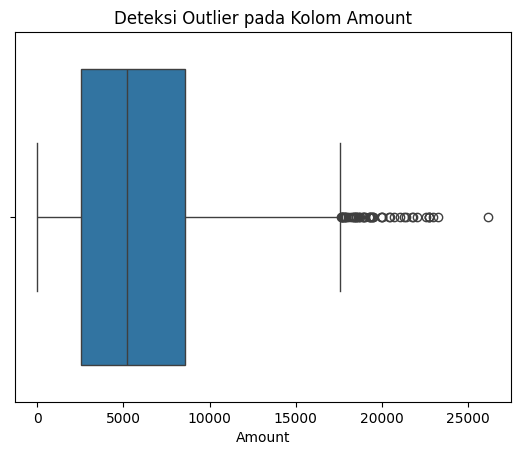

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat Box Plot untuk satu kolom (Amount)
sns.boxplot(x=df['Amount'])
plt.title('Deteksi Outlier pada Kolom Amount')
plt.show()


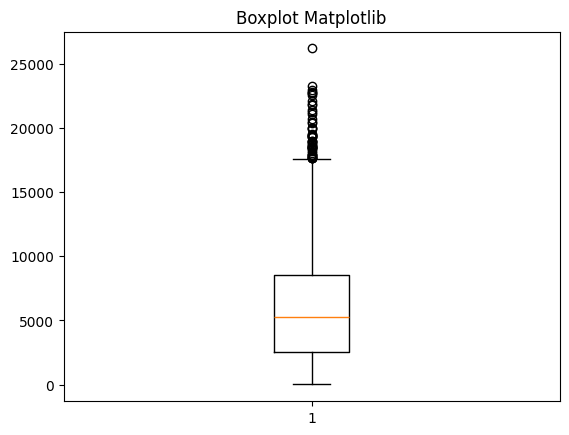

In [14]:
import matplotlib.pyplot as plt
plt.boxplot(df['Amount'])
plt.title("Boxplot Matplotlib")
plt.show()


In [15]:
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Cluster_Label
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,5320.00,180,4
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,7896.00,94,0
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,4501.00,91,3
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,12726.00,342,2
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,13685.00,184,2
...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,5303.58,354,1
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,7339.32,121,0
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,616.09,238,4
3280,Dotty Strutley,India,Eclairs,28/07/2024,2504.62,397,1


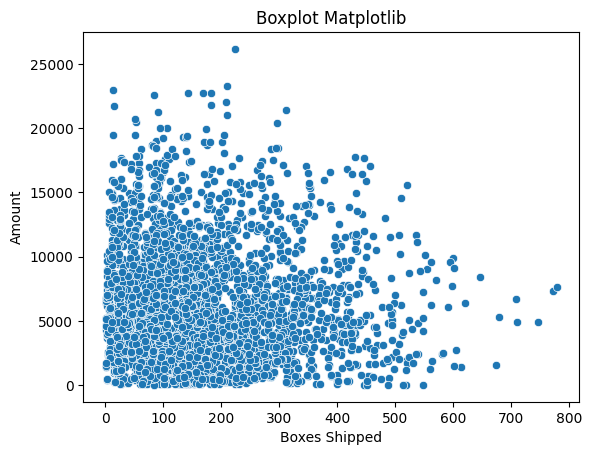

In [16]:
sns.scatterplot(data=df, x='Boxes Shipped', y= 'Amount')
plt.title("Boxplot Matplotlib")
plt.show()

In [17]:
#hilangakan pencilan data
Q1= df['Amount'].quantile(0.25)
Q3= df['Amount'].quantile(0.75)
IQR= Q3-Q1
#tentukan batas pagar
IQR_Lower= Q1-1.5*IQR
IQR_Upper= Q3+1.5*IQR
# Filter data: hanya ambil yang di dalam pagar
df_filtered= df[(df['Amount']>= IQR_Lower)&(df['Amount']<=IQR_Upper)]
df_filtered

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Cluster_Label
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,5320.00,180,4
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,7896.00,94,0
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,4501.00,91,3
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,12726.00,342,2
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,13685.00,184,2
...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,5303.58,354,1
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,7339.32,121,0
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,616.09,238,4
3280,Dotty Strutley,India,Eclairs,28/07/2024,2504.62,397,1


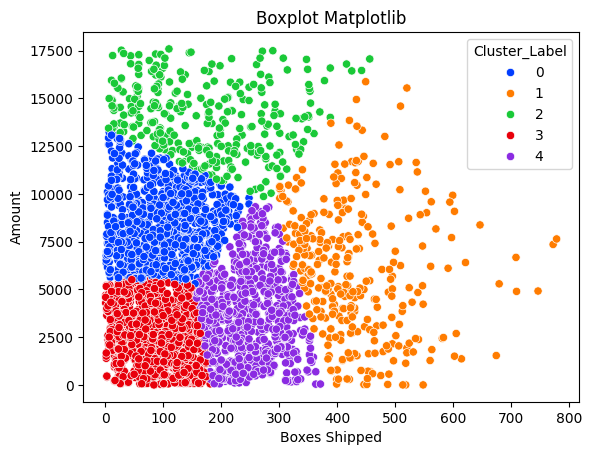

In [18]:
# scatterplot dengan pengelompokan
sns.scatterplot(data=df_filtered, x='Boxes Shipped', y= 'Amount', hue='Cluster_Label', palette='bright')
plt.title("Boxplot Matplotlib")
plt.show()

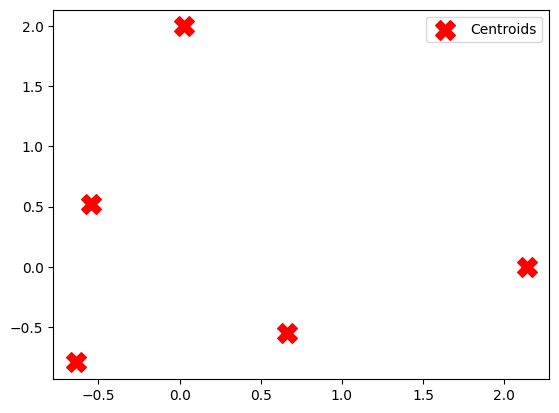

In [19]:
#Centroid/ titik tengah
# Ambil koordinat pusat dari model kmeans
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')
plt.legend()
plt.show()

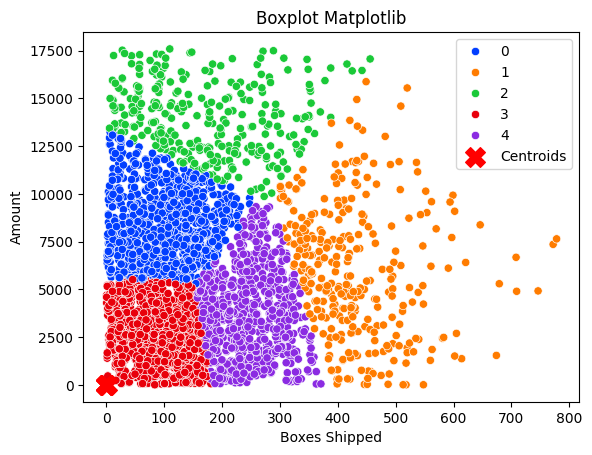

In [20]:
#gabungan scatterplot dan centroids
# scatterplot dengan pengelompokan
sns.scatterplot(data=df_filtered, x='Boxes Shipped', y= 'Amount', hue='Cluster_Label', palette='bright')
plt.title("Boxplot Matplotlib")
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')
plt.legend()
plt.show()

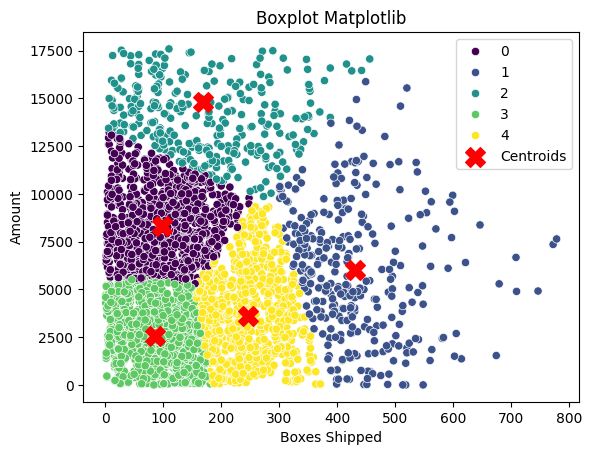

In [21]:
#gabungan scatterplot dan centroids
# scatterplot dengan pengelompokan
sns.scatterplot(data=df_filtered, x='Boxes Shipped', y= 'Amount', hue='Cluster_Label', palette='viridis')
plt.title("Boxplot Matplotlib")
centroidss = kmeans.cluster_centers_
centroids = alat_scalling.inverse_transform(centroidss)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, marker='X', label='Centroids')
plt.legend()
plt.show()

In [22]:
urutan_sales=df_filtered[['Sales Person', 'Amount','Boxes Shipped']]
urutan_sales

,Sales Person,Amount,Boxes Shipped
0,Jehu Rudeforth,5320.00,180
1,Van Tuxwell,7896.00,94
2,Gigi Bohling,4501.00,91
3,Jan Morforth,12726.00,342
4,Jehu Rudeforth,13685.00,184
...,...,...,...
3277,Karlen McCaffrey,5303.58,354
3278,Jehu Rudeforth,7339.32,121
3279,Ches Bonnell,616.09,238
3280,Dotty Strutley,2504.62,397


In [23]:
# Menampilkan orang pertama di Cluster 0
print("Daftar Sales Person di Cluster 0:")
print(df_filtered[df_filtered['Cluster_Label'] == 0]['Sales Person'].unique())

# Menampilkan orang pertama di Cluster 1
print("\nDaftar Sales Person di Cluster 1:")
print(df_filtered[df_filtered['Cluster_Label'] == 1]['Sales Person'].unique())


Daftar Sales Person di Cluster 0:
['Van Tuxwell' "Marney O'Breen" 'Brien Boise' 'Kaine Padly'
 'Dennison Crosswaite' 'Karlen McCaffrey' 'Andria Kimpton'
 'Madelene Upcott' 'Curtice Advani' 'Oby Sorrel' 'Jan Morforth'
 'Gigi Bohling' 'Camilla Castle' 'Roddy Speechley' 'Kelci Walkden'
 'Ches Bonnell' 'Gunar Cockshoot' 'Husein Augar' 'Beverie Moffet'
 'Barr Faughny' 'Jehu Rudeforth' 'Rafaelita Blaksland' 'Mallorie Waber'
 'Dotty Strutley' "Wilone O'Kielt"]

Daftar Sales Person di Cluster 1:
['Beverie Moffet' 'Roddy Speechley' 'Karlen McCaffrey' 'Camilla Castle'
 'Madelene Upcott' 'Dennison Crosswaite' 'Andria Kimpton' 'Kelci Walkden'
 'Jan Morforth' 'Rafaelita Blaksland' "Marney O'Breen" 'Oby Sorrel'
 'Van Tuxwell' 'Jehu Rudeforth' 'Barr Faughny' 'Husein Augar'
 'Mallorie Waber' 'Gunar Cockshoot' 'Ches Bonnell' 'Kaine Padly'
 'Dotty Strutley' 'Gigi Bohling' 'Curtice Advani' 'Brien Boise']


In [24]:
# Melihat rata-rata Amount dan Boxes untuk tiap cluster
analisis_cluster = df_filtered.groupby('Cluster_Label')[['Amount', 'Boxes Shipped']].mean()
print(analisis_cluster)


                     Amount  Boxes Shipped
Cluster_Label                             
0               8309.433912      97.237569
1               6017.695888     429.585670
2              13986.494430     170.661238
3               2543.144941      85.125000
4               3622.741010     245.998536


In [25]:
# Mengelompokkan nama berdasarkan Cluster
hasil_nama = df_filtered.groupby('Cluster_Label')['Sales Person'].unique()

for cluster_id, namam in hasil_nama.items():
    print(f"--- Cluster {cluster_id} ---")
    print(", ".join(namam[:5])) # Menampilkan 5 nama pertama
    print("\n")


--- Cluster 0 ---
Van Tuxwell, Marney O'Breen, Brien Boise, Kaine Padly, Dennison Crosswaite


--- Cluster 1 ---
Beverie Moffet, Roddy Speechley, Karlen McCaffrey, Camilla Castle, Madelene Upcott


--- Cluster 2 ---
Jan Morforth, Jehu Rudeforth, Oby Sorrel, Rafaelita Blaksland, Karlen McCaffrey


--- Cluster 3 ---
Gigi Bohling, Van Tuxwell, Gunar Cockshoot, Jehu Rudeforth, Brien Boise


--- Cluster 4 ---
Jehu Rudeforth, Mallorie Waber, Beverie Moffet, Marney O'Breen, Karlen McCaffrey




In [26]:
# Lihat performance tiap sales
# Membuat tabel silang (Crosstab) antara Sales Person dan Cluster
sales_performance = pd.crosstab(df_filtered['Sales Person'], df_filtered['Cluster_Label'])

# Menghitung total transaksi per Sales Person
sales_performance['Total_Transactions'] = sales_performance.sum(axis=1)

# Menampilkan tabel (diurutkan berdasarkan transaksi terbanyak)
print(sales_performance.sort_values(by='Total_Transactions', ascending=False))


Cluster_Label         0   1   2   3   4  Total_Transactions
Sales Person                                               
Kelci Walkden        34  15  12  69  28                 158
Brien Boise          41  10  24  48  31                 154
Beverie Moffet       37  16  18  47  32                 150
Van Tuxwell          48   9  13  56  21                 147
Dennison Crosswaite  38  19  15  42  31                 145
Oby Sorrel           48  22  13  31  31                 145
Gigi Bohling         45   8  10  57  21                 141
Ches Bonnell         46  12  19  30  33                 140
Karlen McCaffrey     26  22  10  41  41                 140
Curtice Advani       29  12   9  52  33                 135
Madelene Upcott      57  19  15  27  16                 134
Marney O'Breen       46  19  11  31  25                 132
Kaine Padly          52  12   9  22  36                 131
Roddy Speechley      30   9  13  43  34                 129
Gunar Cockshoot      36  15  18  40  20 

In [27]:
# Tempat dengan penjualan terbanyak
tmpt=df_filtered[['Country','Boxes Shipped']]
tmpt

,Country,Boxes Shipped
0,UK,180
1,India,94
2,India,91
3,Australia,342
4,UK,184
...,...,...
3277,Australia,354
3278,USA,121
3279,Canada,238
3280,India,397


In [28]:
# Tempat dengan penjualan terbanyak
tmpt=df_filtered.groupby('Country')['Boxes Shipped'].count().sort_values(ascending=False)
tmpt

,Boxes Shipped
Country,
Australia,608
India,537
USA,528
UK,528
Canada,520
New Zealand,511


In [29]:
# Tempat dengan penjualan terbanyak
tmpt=df_filtered.groupby('Country')['Boxes Shipped'].sum().sort_values(ascending=False)
tmpt

,Boxes Shipped
Country,
Australia,99179
Canada,93931
UK,91730
India,87382
USA,80440
New Zealand,80132


In [30]:
tmpt_lengkap = df_filtered.groupby('Country').agg({
    'Boxes Shipped': ['count', 'sum'],  # Berapa kali order & Total boxnya
    'Amount': 'sum'                     # Total uang yang masuk
}).sort_values(by=('Boxes Shipped', 'sum'), ascending=False)

print(tmpt_lengkap)


            Boxes Shipped             Amount
                    count    sum         sum
Country                                     
Australia             608  99179  3506927.59
Canada                520  93931  2988159.14
UK                    528  91730  3243166.00
India                 537  87382  3032062.55
USA                   528  80440  3146762.21
New Zealand           511  80132  2886661.74


In [31]:
rekap = df_filtered.groupby('Country').agg({
    'Amount': ['sum', 'mean'],           # Total uang & Rata-rata uang
    'Product': ['max', 'nunique'], # Kiriman paling banyak & Berapa kali kirim (unik)
    'Sales Person': 'nunique'            # Ada berapa sales yang kerja di sana?
})
print(rekap)


                 Amount                  Product         Sales Person
                    sum         mean         max nunique      nunique
Country                                                              
Australia    3506927.59  5767.973010  White Choc      22           25
Canada       2988159.14  5746.459885  White Choc      22           25
India        3032062.55  5646.298976  White Choc      22           25
New Zealand  2886661.74  5649.044501  White Choc      22           25
UK           3243166.00  6142.359848  White Choc      22           25
USA          3146762.21  5959.776913  White Choc      22           25


In [32]:
# Menghitung total box per Negara dan per Produk
stok_produk = df_filtered.groupby(['Country', 'Product'])['Boxes Shipped'].sum().reset_index()

# Urutkan dari yang paling banyak terjual
stok_produk = stok_produk.sort_values(by=['Country', 'Boxes Shipped'], ascending=[True, False])
print(stok_produk)


       Country               Product  Boxes Shipped
0    Australia        50% Dark Bites           9692
5    Australia          Almond Choco           6660
1    Australia        70% Dark Bites           6389
20   Australia   Spicy Special Slims           6315
13   Australia             Milk Bars           5587
..         ...                   ...            ...
126        USA   Organic Choco Syrup           2337
124        USA       Mint Chip Choco           2229
111        USA        70% Dark Bites           1911
116        USA   Baker's Choco Chips           1271
118        USA  Choco Coated Almonds           1015

[132 rows x 3 columns]


In [33]:
kebutuhan_stok = df_filtered.groupby(['Country', 'Product']).agg({
    'Boxes Shipped': ['sum', 'mean', 'count']
})


In [34]:
with pd.ExcelWriter('Laporan_Final_Cokelat.xlsx') as writer:
    stok_produk.to_excel(writer, sheet_name='Data_Stok', index=False)
    sales_performance.to_excel(writer, sheet_name='Performa_Sales', index=True)
    # Perintah untuk download otomatis ke komputer
files.download('Laporan_Final_Cokelat.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>